In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,FunctionTransformer
from category_encoders import CountEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("cleaned_ai_adoption_data.csv")

In [3]:
def engineering_logic(X):
    # working on a copy to avoid SettingWithCopy warnings
    X = X.copy()
    
    # Division by zero protection (+ 1)
    X['budget_per_project'] = X['ai_budget_percentage'] / (X['ai_projects_active'] + 1)
    X['investment_per_tool'] = X['ai_investment_per_employee'] / (X['num_ai_tools_used'] + 1)
    
    X['success_rate'] = 1 - X['ai_failure_rate']
    X['effective_budget'] = X['ai_budget_percentage'] * X['success_rate']
    
    X['maturity_x_adoption'] = X['ai_maturity_score'] * X['ai_adoption_rate']
    X['experience_factor'] = X['years_using_ai'] * X['ai_maturity_score']
    
    X['projects_per_tool'] = X['ai_projects_active'] / (X['num_ai_tools_used'] + 1)
    X['revenue_per_ai_investment'] = X['annual_revenue_usd_millions'] / (X['ai_investment_per_employee'] + 1)

    X = X.drop(columns =["ai_budget_percentage","num_ai_tools_used","ai_projects_active","ai_investment_per_employee"])
    
    return X


In [4]:
# Feature Creator
feature_engineer = FunctionTransformer(engineering_logic)

In [5]:
df.shape

(110101, 15)

In [6]:
df.columns.get_loc('company_size')

1

In [7]:
df.columns.get_indexer(["company_size", "ai_adoption_stage"])

array([1, 4])

In [8]:
trf1 = ColumnTransformer(
    transformers=[
        ('ordinal_company', OrdinalEncoder(categories=[["Startup", "SME", "Enterprise"]]), ['company_size']),
        ('ordinal_ai', OrdinalEncoder(categories=[["none", "pilot", "partial", "full"]]), ['ai_adoption_stage']),
        ('onehot_industry', OneHotEncoder(drop='first', handle_unknown="ignore", sparse_output=False), ['industry_grouped']),
        ('freq_country', CountEncoder(normalize=True), ['country'])
    ],
    remainder='passthrough'
)

In [9]:
df.shape

(110101, 15)

In [10]:
# feature selection
from sklearn.feature_selection import SelectKBest,f_classif
trf2 = SelectKBest(score_func=f_classif,k=10)

In [11]:
# train the model
trf3 = RandomForestRegressor(n_estimators=200,max_depth=8, random_state=42)

# Create Pipeline

In [12]:
pipe = make_pipeline(feature_engineer,trf1,trf2,trf3)

In [13]:
from sklearn import set_config
set_config(transform_output="pandas")

In [14]:
y = df["ROI"]
X = df.drop(columns="ROI")

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
X_train.shape

(88080, 14)

In [17]:
y_train.shape

(88080,)

In [18]:
pipe.fit(X_train, y_train)

C:\Users\KHUSHI COMPUTERS\Desktop\jupyter projects\mynewv\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function engineering_logic at 0x0000026A1CE61E40>)),
                ('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_company',
                                                  OrdinalEncoder(categories=[['Startup',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['company_size']),
                                                 ('ordinal_ai',
                                                  OrdinalEncoder(categories=[['none',
                                                                              'pilot',
                                                                              'part...
                                                  ['ai_adoption_stage']),
                                                 ('onehot_industry',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['industry_grouped']),
                                                 ('freq_country',
                                                  CountEncoder(combine_min_nan_groups=True,
                                                               normalize=True),
                                                  ['country'])])),
                ('selectkbest', SelectKBest()),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=8, n_estimators=200,
                                       random_state=42))])

In [19]:
y_pred = pipe.predict(X_test)

In [20]:
r2_score = pipe.score(X_test, y_test)
print(f"R^2 Score: {r2_score:.4f}")

R^2 Score: 0.4552


In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"On average, my predictions are off by: {mae}")

On average, my predictions are off by: 0.7153717392665763


In [22]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
print("Baseline MAE:", mean_absolute_error(y_test, dummy.predict(X_test)))

Baseline MAE: 0.9824309606517758


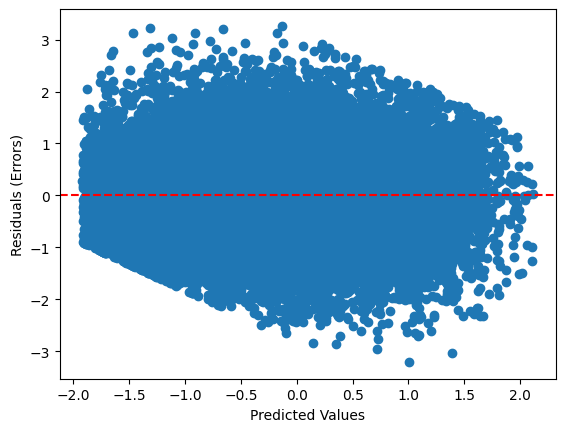

In [23]:
import matplotlib.pyplot as plt
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.show()

Model is learning something.

A "Dummy" guess that just predicts the average every time is off by 0.98, 
while your model is off by 0.71. You have improved upon a "blind guess" by about 27%.

In [24]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Define the pipeline
pipe_xgb = Pipeline([
    ('engineering', feature_engineer),
    ('pre1', trf1),
    ('selectkbest', trf2),
    ('xgb', model)
])

# Fit the pipeline
pipe_xgb.fit(X_train, y_train)

C:\Users\KHUSHI COMPUTERS\Desktop\jupyter projects\mynewv\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('engineering',
                 FunctionTransformer(func=<function engineering_logic at 0x0000026A1CE61E40>)),
                ('pre1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_company',
                                                  OrdinalEncoder(categories=[['Startup',
                                                                              'SME',
                                                                              'Enterprise']]),
                                                  ['company_size']),
                                                 ('ordinal_ai',
                                                  OrdinalEncoder(categories=[['none',
                                                                              'pilot',
                                                                              'partial',
                                                                              'full']]),
                                                  ['ai_a...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [28]:
y_pred = pipe_xgb.predict(X_test)

In [30]:
from sklearn.metrics import r2_score

xgb_r2_score = r2_score(y_test, y_pred)
print(f"R^2 Score: {xgb_r2_score}")

R^2 Score: 0.4539124501195245


# Hyperparameter tunning 

In [31]:
from sklearn.model_selection import GridSearchCV
# hallow trees + slow learning
param_grid = {
    'xgb__n_estimators': [500, 1000],
    'xgb__learning_rate': [0.01, 0.05],
    'xgb__max_depth': [3, 5],    
    'xgb__subsample': [0.8],
    'xgb__colsample_bytree': [0.8],
    'xgb__gamma': [0, 0.1]
}


# n_jobs=-1 uses all your CPU cores to speed up the process
grid_search = GridSearchCV(pipe_xgb, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


C:\Users\KHUSHI COMPUTERS\Desktop\jupyter projects\mynewv\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('engineering',
                                        FunctionTransformer(func=<function engineering_logic at 0x0000026A1CE61E40>)),
                                       ('pre1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal_company',
                                                                         OrdinalEncoder(categories=[['Startup',
                                                                                                     'SME',
                                                                                                     'Enterprise']]),
                                                                         ['company_size']),
                                                                        ('ordinal_ai',
                                                                         OrdinalEncoder(categories=[['none',
                                                                                                     'pilot...
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=500,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.8], 'xgb__gamma': [0, 0.1],
                         'xgb__learning_rate': [0.01, 0.05],
                         'xgb__max_depth': [3, 5],
                         'xgb__n_estimators': [500, 1000],
                         'xgb__subsample': [0.8]},
             scoring='r2', verbose=1)

In [32]:
best_pipe = grid_search.best_estimator_
y_pred = best_pipe.predict(X_test)

print("Final Results: ")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Final Results: 
Best CV R2 Score: 0.4605
Test R2 Score: 0.4562
Test MAE: 0.7150
Best Parameters: {'xgb__colsample_bytree': 0.8, 'xgb__gamma': 0, 'xgb__learning_rate': 0.01, 'xgb__max_depth': 3, 'xgb__n_estimators': 500, 'xgb__subsample': 0.8}


In [33]:
import joblib

# Save the best pipeline 
joblib.dump(best_pipe, 'best_xgb_model.pkl')

# we can use it later:
# loaded_model = joblib.load('best_xgb_model.pkl')

['best_xgb_model.pkl']

In [34]:
X_train.columns

Index(['country', 'company_size', 'annual_revenue_usd_millions',
       'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
       'ai_maturity_score', 'num_ai_tools_used', 'ai_projects_active',
       'ai_budget_percentage', 'ai_failure_rate', 'ai_investment_per_employee',
       'industry_grouped', 'uses_advanced_ai_tool'],
      dtype='object')

In [35]:
def predict_roi(input_dict):
    input_df = pd.DataFrame([input_dict])
    prediction = best_pipe.predict(input_df)
    return prediction[0]

In [36]:
sample_input = {
    'country': 'India',
    'company_size': 'SME',
    'annual_revenue_usd_millions': 50,
    'ai_adoption_rate': 0.6,
    'ai_adoption_stage':"partial",
    'years_using_ai': 7,
    'ai_maturity_score':60,
    'num_ai_tools_used':7,
    'ai_projects_active':5,
    'ai_budget_percentage':15,
    'ai_failure_rate':0.2,
    'ai_investment_per_employee':1200,
    'industry_grouped': "Retail",
    'uses_advanced_ai_tool': "Claude"
}

In [37]:
input_df = pd.DataFrame([sample_input])
prediction = best_pipe.predict(input_df)
print("Predicted ROI:", prediction[0])

Predicted ROI: 1.645704
